In [1]:
### STEP1: - Importing Different Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [3]:
### STEP2: - Loading the data in the dataframe and printing it.
df = pd.read_csv('drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


C:\Users\rsodh\AppData\Local\Temp\ipykernel_12088\974635642.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=raw_df, ax=ax[0, 0], palette='pastel')
C:\Users\rsodh\AppData\Local\Temp\ipykernel_12088\974635642.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='BP', data=raw_df, ax=ax[0, 1], palette='pastel')
C:\Users\rsodh\AppData\Local\Temp\ipykernel_12088\974635642.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cholesterol', data=raw_df, ax=ax[1, 0], palette='pastel')
C:\Users\rsodh\AppData\Local\Temp\ipyk

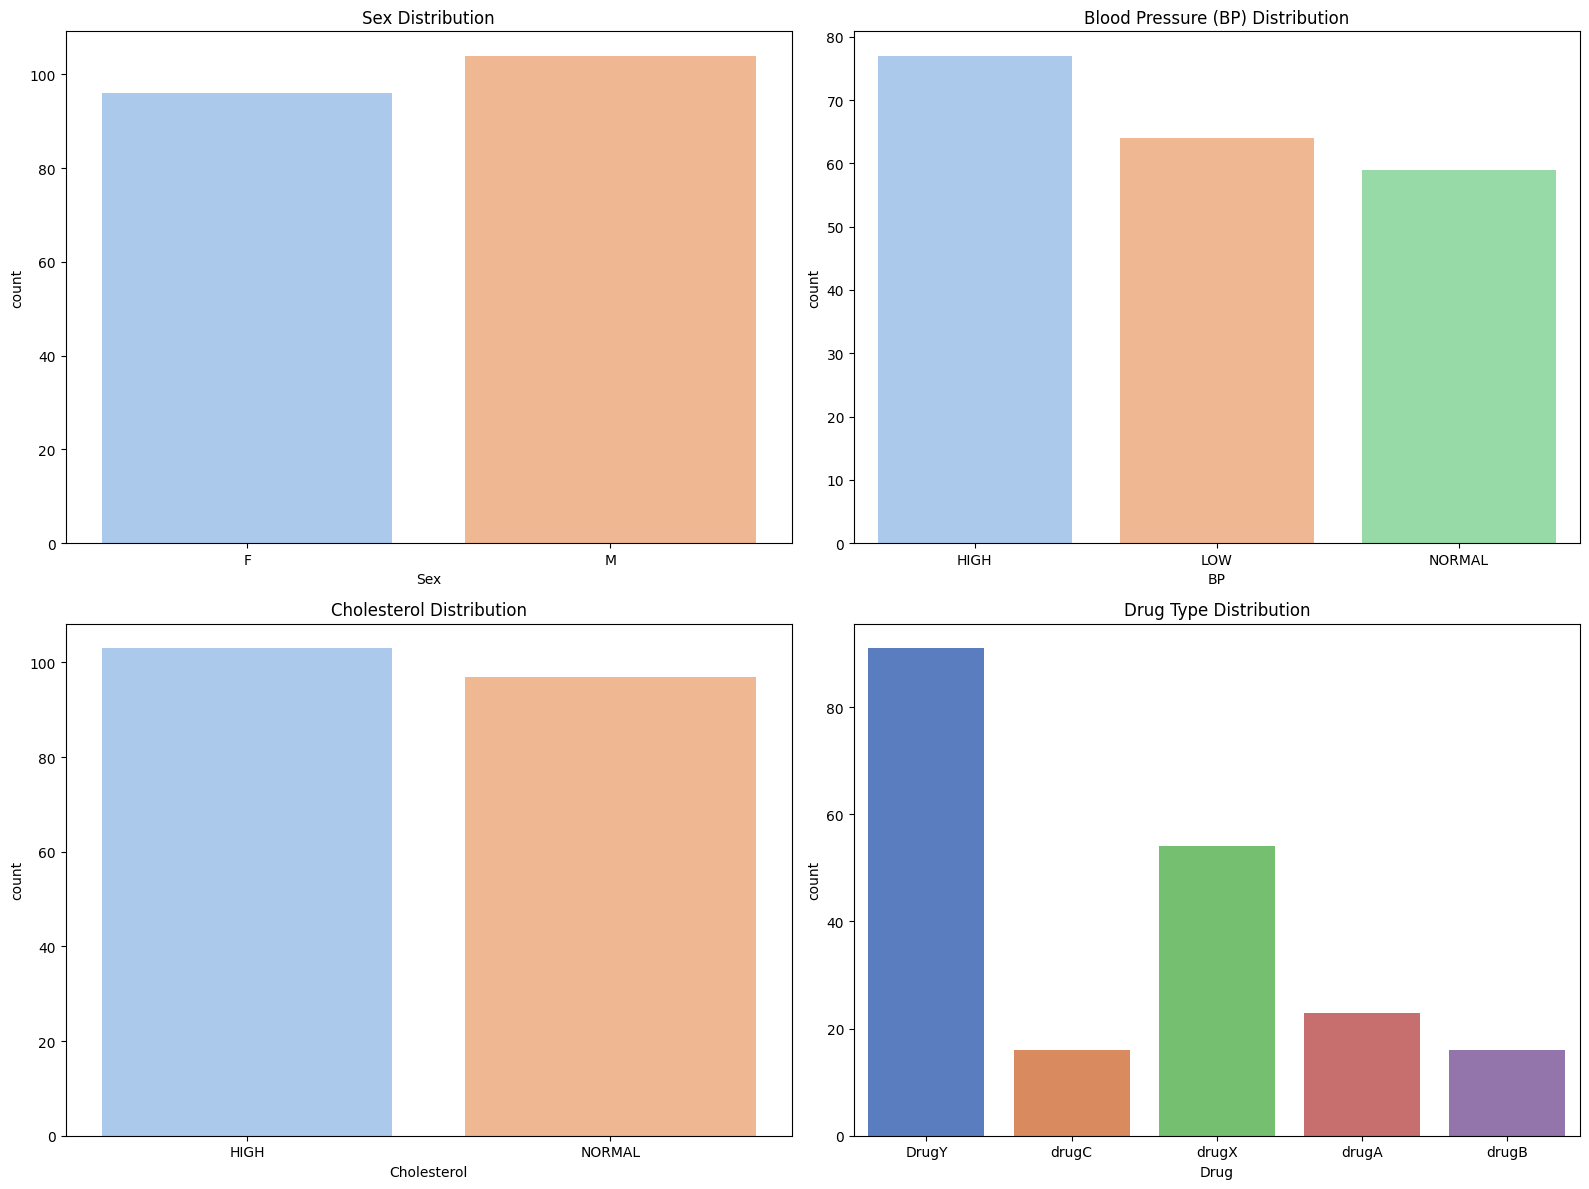

In [5]:
### STEP3: - Exploratory Data Analysis
raw_df = pd.read_csv('drug200.csv')

fig, ax = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(x='Sex', data=raw_df, ax=ax[0, 0], palette='pastel')
ax[0, 0].set_title('Sex Distribution')

sns.countplot(x='BP', data=raw_df, ax=ax[0, 1], palette='pastel')
ax[0, 1].set_title('Blood Pressure (BP) Distribution')

sns.countplot(x='Cholesterol', data=raw_df, ax=ax[1, 0], palette='pastel')
ax[1, 0].set_title('Cholesterol Distribution')

sns.countplot(x='Drug', data=raw_df, ax=ax[1, 1], palette='muted')
ax[1, 1].set_title('Drug Type Distribution')

plt.tight_layout()
plt.show()

In [6]:
### STEP4: -Feature Engineering: Creating features
df['Age_to_NaRatio'] = df['Age'] / df['Na_to_K']
df['Age_Na'] = df['Age'] * df['Na_to_K']
df['Na_squared'] = df['Na_to_K'] ** 2

In [7]:
### STEP5: -Data preprocessing
df = pd.get_dummies(df, columns=['Sex', 'BP', 'Cholesterol'])

# Encode target variable
le = LabelEncoder()
df['Drug'] = le.fit_transform(df['Drug'])

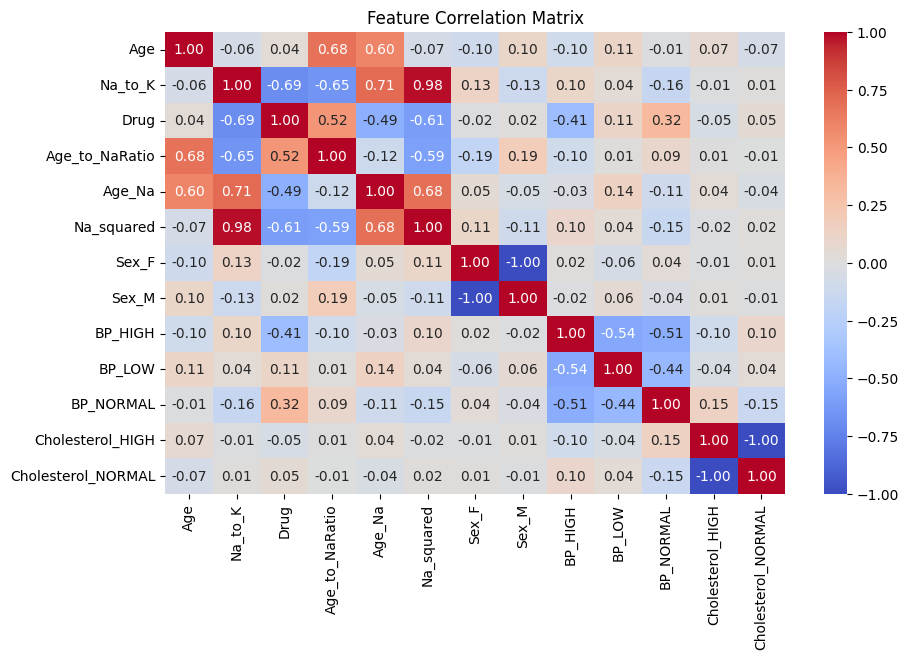

In [8]:
### STEP6: -Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
### STEP7: -Split features and give model a target (drug)
X = df.drop('Drug', axis=1)
y = df['Drug']

In [10]:
### STEP8: -Using SMOTE to handle the imabalance in classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Balanced Class Distribution:\n", pd.Series(y_resampled).value_counts())

Balanced Class Distribution:
 Drug
0    91
3    91
4    91
1    91
2    91
Name: count, dtype: int64


In [11]:
### STEP9: -Splitting the data set and testing the model
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)
print("Train Set Class Distribution:\n", pd.Series(y_train).value_counts())
print("Test Set Class Distribution:\n", pd.Series(y_test).value_counts())

Train Set Class Distribution:
 Drug
2    73
1    73
4    73
0    73
3    72
Name: count, dtype: int64
Test Set Class Distribution:
 Drug
3    19
2    18
0    18
1    18
4    18
Name: count, dtype: int64


In [12]:
### STEP10: -training the XGBoost (XGBClassifier) model
xgb_model = XGBClassifier(
    max_depth=8,
    n_estimators=500,
    learning_rate=0.02,
    subsample=1,
    colsample_bytree=1,
    use_label_encoder=False,
    eval_metric='merror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

C:\Users\rsodh\PycharmProjects\PythonProject2\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [12:47:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='merror', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
### STEP11: -Showcasing the results of the tests
y_pred = xgb_model.predict(X_test)

print("✅ Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))

✅ Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        18

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


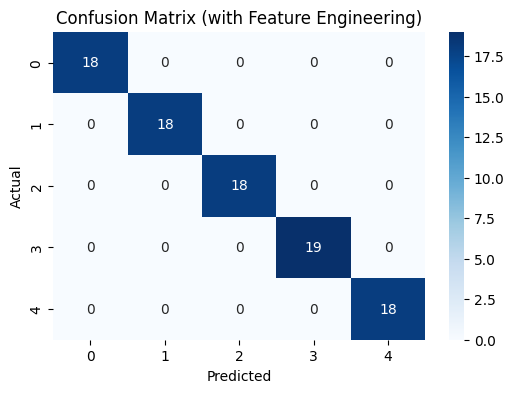

In [14]:
### STEP12: -Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (with Feature Engineering)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\rsodh\AppData\Local\Temp\ipykernel_12088\1907320198.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[sorted_idx], y=features[sorted_idx], palette='viridis')


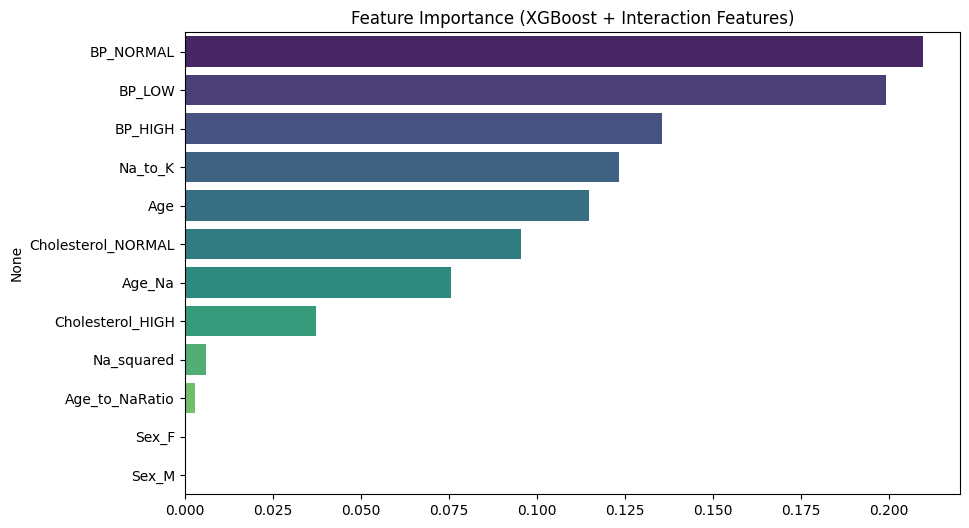

In [15]:
### STEP13: -Feature Importance
importances = xgb_model.feature_importances_
features = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[sorted_idx], y=features[sorted_idx], palette='viridis')
plt.title("Feature Importance (XGBoost + Interaction Features)")
plt.show()